In [1]:
'''
Author: LiuSheng
Date: 2025-03-20 10:29:26
LastEditTime: 2025-03-20 10:36:25
Description: 
'''
import os
import numpy as np
from glob import glob
import SimpleITK as sitk
import matplotlib.pyplot as plt

from cardiac.segment.seg319.utils import read_sitk_img
# from cardiac.segment.seg319.seg319 import lv_segment

from cardiac.bulleye_gen import gen_bulleye

In [2]:
'''
Author: LiuSheng
Date: 2025-03-20 09:41:37
LastEditTime: 2025-03-21 09:53:26
Description: 
'''
import numpy as np
import copy
import json

from cardiac.segment.seg319.sub_func import init_img3d
from cardiac.segment.seg319.sub_func import naive_segment_lv_mask
from cardiac.segment.seg319.sub_func import naive_cal_circle_param
from cardiac.segment.seg319.sub_func import determine_apex_base
from cardiac.segment.seg319.sub_func import cal_sector_masks
from cardiac.segment.seg319.sub_func import select_points
from cardiac.segment.seg319.sub_func import create_triangles
from cardiac.segment.seg319.sub_func import mesh_voxelize

from cardiac.segment.seg319.visualize import plot_for_naive_cal_circle_param
from cardiac.segment.seg319.visualize import show_3d_mask
from cardiac.segment.seg319.visualize import show_mesh

def lv_segment(img3d, voxel_size, verbose=0, save_dir=None):
    img3d = img3d+0
    img3d[img3d<0] = 0
    
    print("************************************************************************************************")
    print(f"input img3d: {img3d.shape}, voxel_size: {voxel_size}")
    print("************************************************************************************************")
    
    # 初始化
    img3d = init_img3d(img3d)
    # 粗分割 mask
    naive_lv_mask = naive_segment_lv_mask(img3d, voxel_size)
    # 定位 center radius
    circle_param, others = naive_cal_circle_param(img3d, naive_lv_mask)
    # 定位 apex_z, base_z
    loc_info = determine_apex_base(img3d, circle_param)
    naive_param = copy.deepcopy(circle_param)
    naive_param.update(loc_info)
    
    print(f"naive_param: {json.dumps(naive_param, indent=4)}")
    
    if verbose:
        plot_for_naive_cal_circle_param(others["summed_img2d"], others["intensity_mask"], naive_param, others["mask_inner"])
    
    
    ### 这里可以添加微调位置: naive_param
    sector_masks, points_theoretical = cal_sector_masks(img3d, naive_param, verbose=0)
    
    points = select_points(img3d, sector_masks, points_theoretical)
    triangles = create_triangles(points)
    if verbose:
        show_mesh(points, triangles, save_dir)
    
    mask_array = mesh_voxelize(img3d, points, triangles)
    
    if verbose:
        show_3d_mask(mask_array, save_dir)
    
    return mask_array, naive_param



In [3]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import normalized_root_mse as nrmse

def cal_metric(std_polar_map, input_polar_map):

    # 计算 PSNR
    psnr_value = psnr(std_polar_map, input_polar_map, data_range=std_polar_map.max() - std_polar_map.min())

    ssim_value = ssim(std_polar_map, input_polar_map, data_range=std_polar_map.max() - std_polar_map.min())
    # 计算 NRMSE
    nrmse_value = nrmse(std_polar_map, input_polar_map)


    print(f"PSNR: {psnr_value}, SSIM: {ssim_value}, NRMSE: {nrmse_value}")
    
    return psnr_value, ssim_value, nrmse_value

In [4]:
def show_bulleye(std_bulleye, gen_bulleye, save_dir=None):
    fig = plt.figure(figsize=(10, 3))

    # 第一个子图
    ax1 = plt.subplot(131)
    im1 = ax1.imshow(std_bulleye)
    ax1.set_title("std_bulleye")
    ax1.axis("off")
    plt.colorbar(im1, ax=ax1)

    # 第二个子图
    ax2 = plt.subplot(132)
    im2 = ax2.imshow(gen_bulleye)
    ax2.set_title("gen_bulleye")
    ax2.axis("off")
    plt.colorbar(im2, ax=ax2)

    # 第三个子图
    ax3 = plt.subplot(133)
    im3 = ax3.imshow(std_bulleye - gen_bulleye)
    ax3.set_title("diff: std - gen")
    ax3.axis("off")
    plt.colorbar(im3, ax=ax3)

    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, "bulleye.png"))
    plt.show()


In [5]:
base_dir = r"Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii"


total_data = {}
for patient_id in os.listdir(base_dir):
    if not patient_id.startswith("Patient_00"):
        continue
    patient_dir = os.path.join(base_dir, patient_id)
    
    print("patient_dir",patient_dir)
    gen_polar_map = np.zeros((128,128))
    std_polar_map = np.zeros((128,128))
    for file_name in os.listdir(patient_dir):
        if file_name.startswith("SA"):
            img_path = os.path.join(patient_dir, file_name)
            img3d, voxel_size = read_sitk_img(img_path)
            mask3d, param = lv_segment(img3d, voxel_size, verbose=2)
            # param["dividing_z"] = param["dividing_z"] + 10
            # param["apex_z"] = param["apex_z"] + param["radius"] + 3
            param["dividing_z"] = param["apex_z"] + param["radius"]*1.3 + 3
            # param["base_z"] = param["apex_z"] + max(param["base_z"] - param["apex_z"], 10)
            param["thickness"] = 5
            
            from scipy.ndimage import binary_dilation
            # 结构元素（可定义膨胀方式）
            structure = np.ones((3, 3, 3), dtype=np.uint8)  # 3x3x3 立方体结构
            
            mask3d = binary_dilation(mask3d, structure, iterations=5)
            
            gen_polar_map = gen_bulleye(img3d*mask3d, param)
        if file_name.startswith("Polar"):
            sitk_polar_map = sitk.ReadImage(os.path.join(patient_dir, file_name))
            std_polar_map = sitk.GetArrayFromImage(sitk_polar_map)[0] # 第一帧是静息, 后面是门控
            print(f"std_polar_map: {std_polar_map.shape}")

    show_bulleye(std_polar_map, gen_polar_map, save_dir=patient_dir)
    
    
    psnr_value, ssim_value, nrmse_value = cal_metric(std_polar_map, gen_polar_map)
    
    data = {
        "psnr": psnr_value,
        "ssim": ssim_value,
        "nrmse": nrmse_value
    }
    
    total_data[patient_id] = data
        
    # break

FileNotFoundError: [WinError 3] 系统找不到指定的路径。: 'Y:\\labspace\\DataCollection\\Project\\RadiSmart\\cardiac\\all_nii'

In [15]:
psnrs, ssims, nrmses = [], [], []

for key, info_dic in total_data.items():
    # print(info_dic)
    psnr_value = info_dic["psnr"]
    ssim_value = info_dic["ssim"]
    nrmse_value = info_dic["nrmse"]
    psnrs.append(psnr_value)
    ssims.append(ssim_value)
    nrmses.append(nrmse_value)

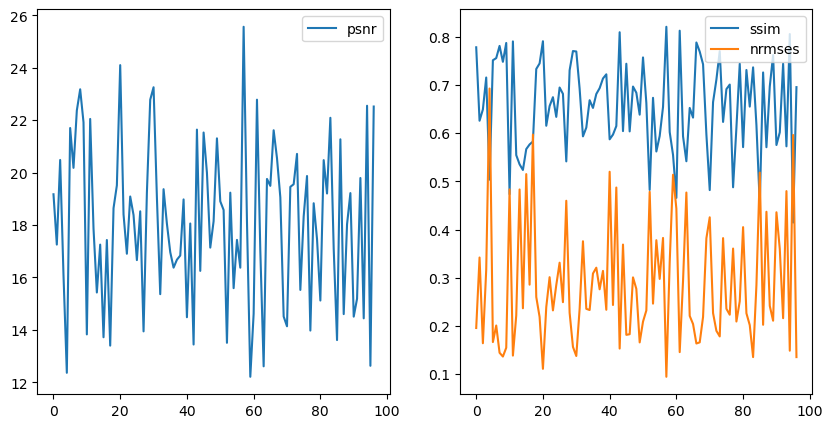

In [16]:
plt.figure(figsize=(10,5))

plt.subplot(121)
plt.plot(psnrs, label="psnr")

plt.legend()


plt.subplot(122)
plt.plot(ssims, label="ssim")
plt.plot(nrmses, label="nrmses")
plt.legend()